In [410]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [411]:
from pathlib import Path

# Path setup (relative to this notebook file) 
notebook_path = Path("plotting.ipynb").resolve()
script_dir = notebook_path.parent 
csv_folder = script_dir / "Auto_Logged_data_March13"

print("Notebook dir:", script_dir)
print("CSV folder:", csv_folder)

Notebook dir: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March13_2026
CSV folder: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March13_2026\Auto_Logged_data_March13


In [412]:
# choose files to plot (all CSVs in the folder)
selected_files = sorted([p.name for p in csv_folder.glob("*.csv")])
print("Selected files:")
for f in selected_files:
    print(f)


Selected files:
Data_March13_PD_CS1.csv
Data_March13_PD_CS2.csv
Data_March13_PD_CS3.csv
Data_March13_PD_CS5.csv
Data_March13_PD_F1.csv


In [413]:
data = {}
for file in selected_files:
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)
    # normalize time for this file
    df["Time"] = df["Time(s)"] - df["Time(s)"].iloc[0]
    # convert to km/h (and keep the original m/s if you want)
    df["Ego_Velocity_kmph"] = df["Ego_Velocity(m/s)"] * 3.6
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Velocity_kmph"] = df["Obs_Velocity(m/s)"] * 3.6

    data[file] = df

    print(file, "loaded")
    display(df.head())

Data_March13_PD_CS1.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000009,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,12.635982,12.635973,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,12.748083,12.748074,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,12.855959,12.855950,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,12.965899,12.965890,0.0,NaN


Data_March13_PD_CS2.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000009,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,1.248120,1.248111,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,1.357877,1.357867,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,1.467689,1.467680,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,1.577563,1.577554,0.0,NaN


Data_March13_PD_CS3.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000019,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,5.603902,5.603883,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,5.715948,5.715929,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,5.824549,5.824530,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,5.935155,5.935136,0.0,NaN


Data_March13_PD_CS5.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000010,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,3.823868,3.823858,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,3.932233,3.932223,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,4.042501,4.042491,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,4.151635,4.151626,0.0,NaN


Data_March13_PD_F1.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000011,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,4.083674,4.083663,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,4.194135,4.194124,0.0,NaN
3,0.0,0.0,19.65,-0.189975,19.65,-0.189975,4.304395,4.304384,0.0,-0.68391
4,0.0,0.0,NaN,NaN,NaN,NaN,4.414385,4.414373,0.0,NaN


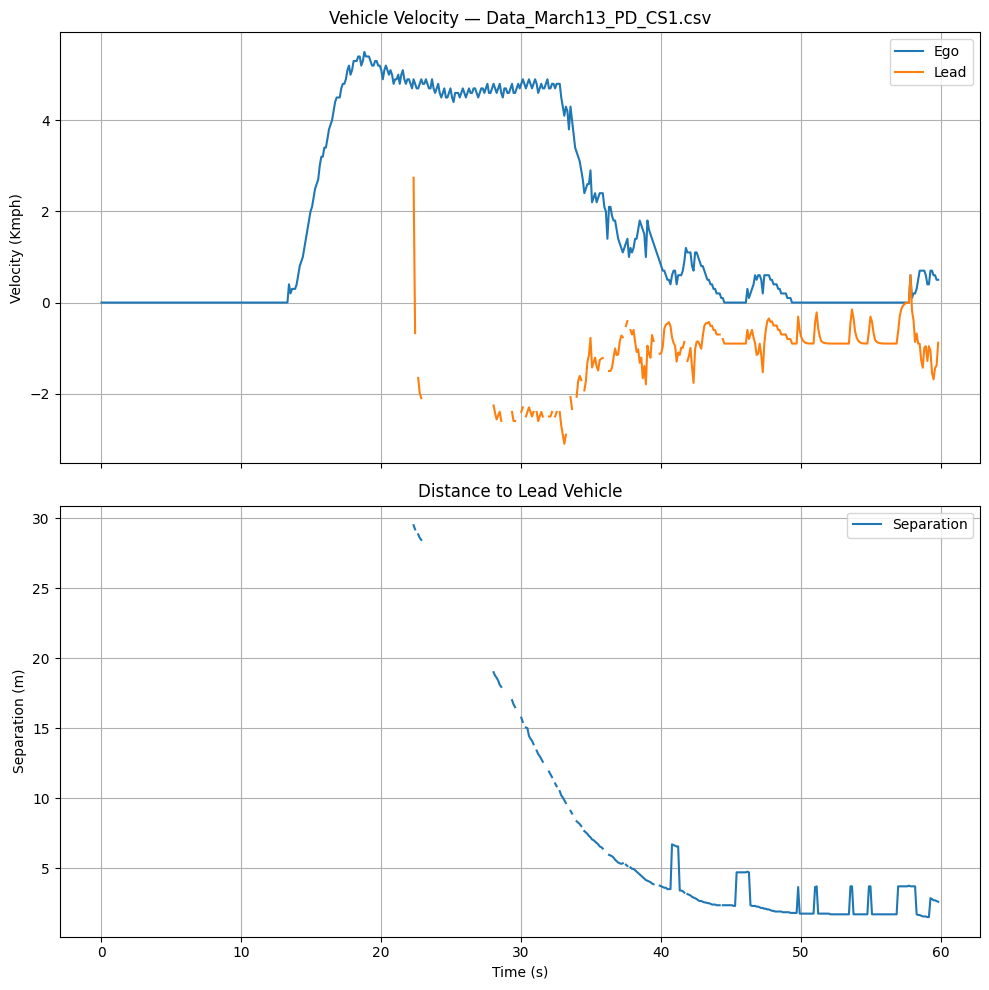

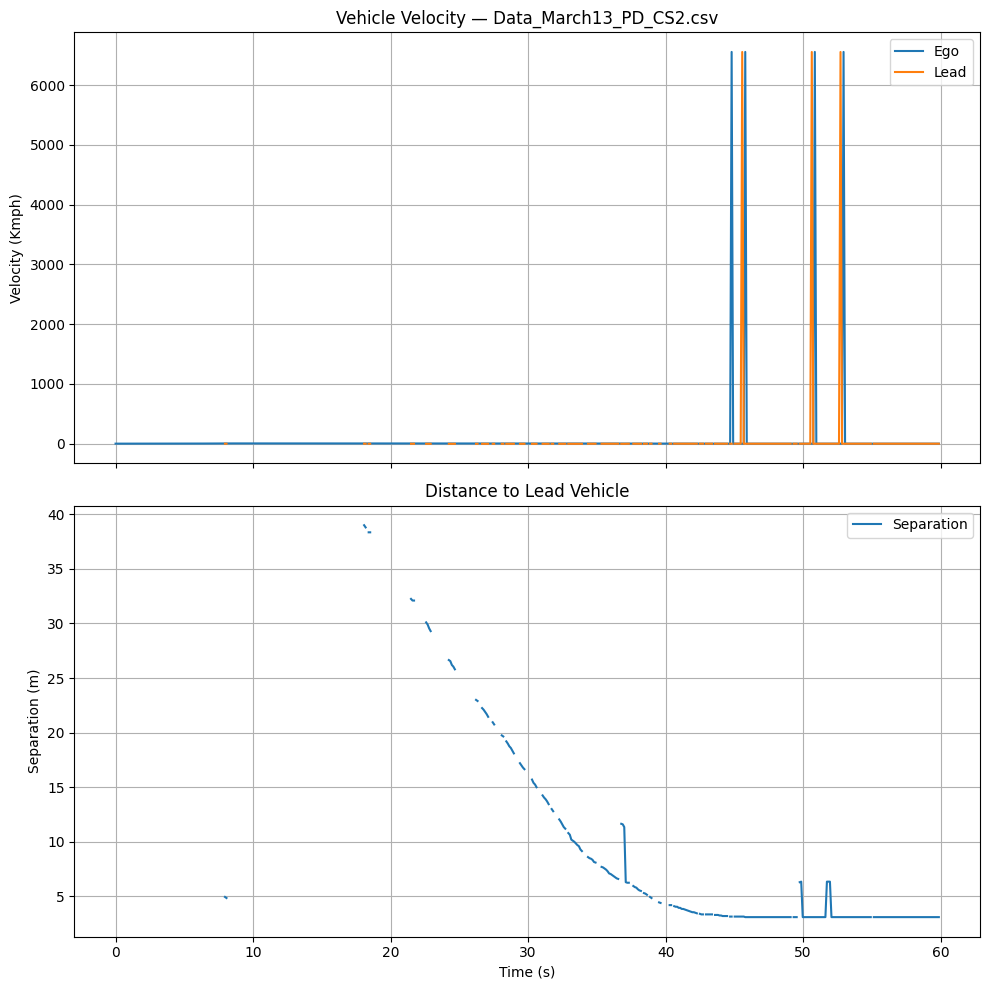

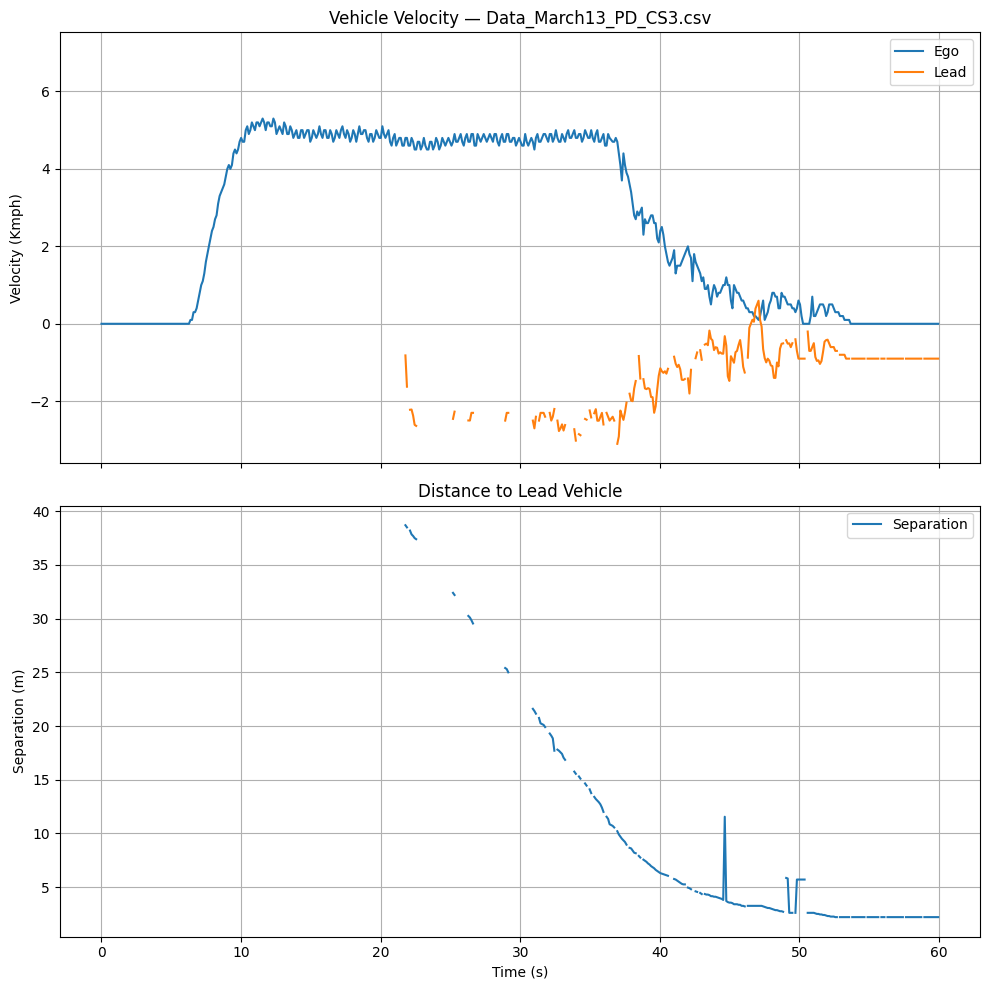

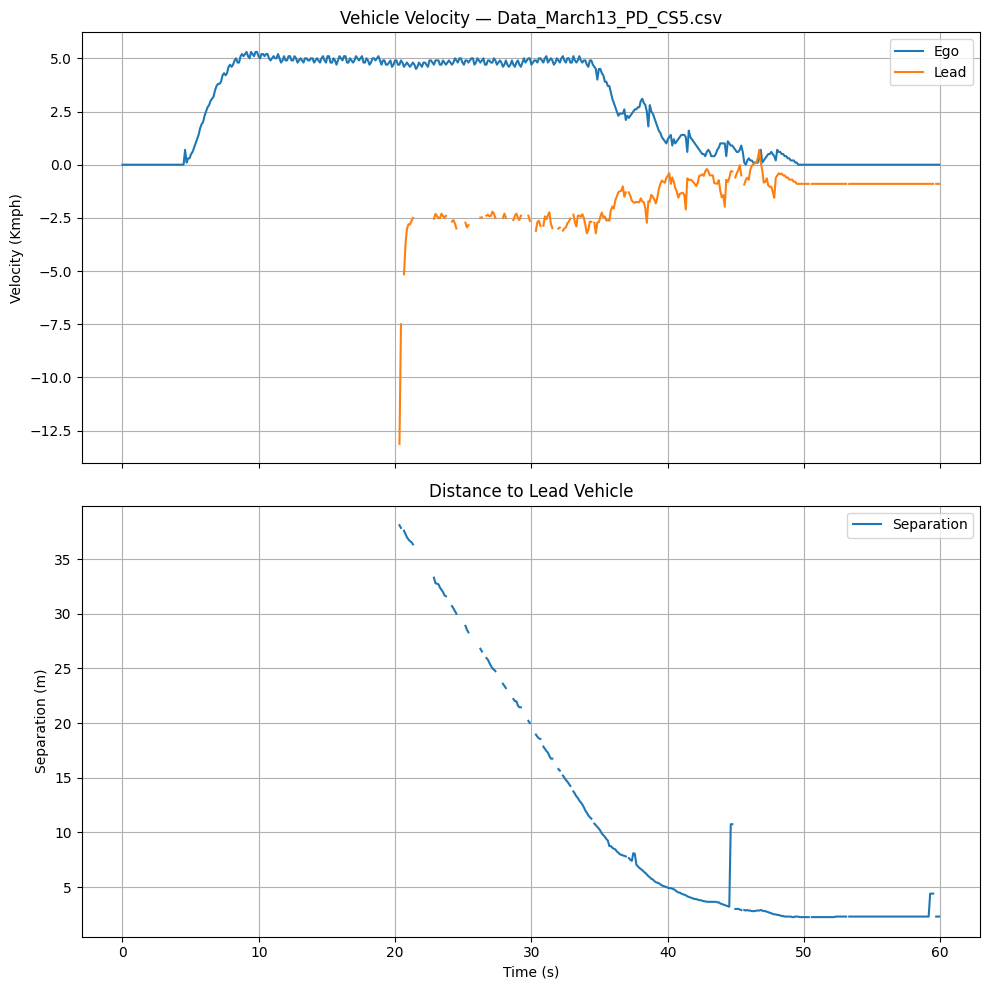

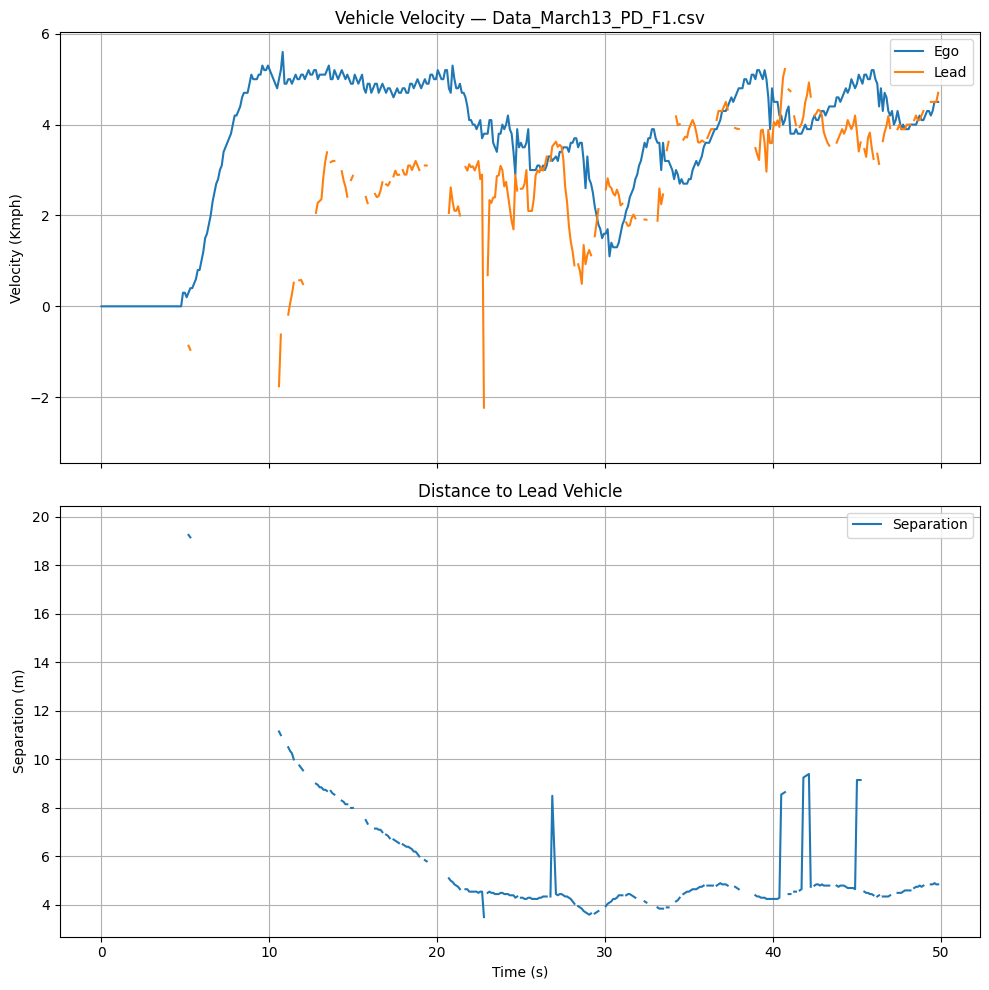

In [414]:
for file, df in data.items():
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # ---- Velocity ----
    axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], label="Ego")
    if "Obs_Velocity_kmph" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_kmph"], linestyle="-", label="Lead")

    # ---- Separation ----
    if "Separation(m)" in df.columns:
        axes[1].plot(df["Time"], df["Separation(m)"], label="Separation")

    axes[0].set_ylabel("Velocity (Kmph)")
    axes[0].set_title(f"Vehicle Velocity — {file}")

    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Distance to Lead Vehicle")

    for ax in axes:
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()

In [415]:
def clean_velocity_series(series,
                          min_val=0.0,
                          max_val=25.0,
                          max_delta_per_step=5.0,
                          rolling_window=5,
                          interp_limit=3):
    """
    Clean a velocity series (m/s) by:
      - coercing to numeric
      - clipping to [min_val, max_val]
      - removing spikes when diff > max_delta_per_step
      - interpolating small gaps
      - smoothing with rolling median
    """
    s = pd.to_numeric(series, errors="coerce")

    # basic clip to physical range
    s = s.clip(lower=min_val, upper=max_val)

    # remove spikes: if step jump bigger than threshold, set to NaN
    delta = s.diff().abs()
    spikes = delta > max_delta_per_step
    s.loc[spikes] = pd.NA

    # fill short gaps by interpolation
    s = s.interpolate(limit=interp_limit, limit_direction="both")

    # optionally smooth a bit
    s = s.rolling(window=rolling_window, center=True, min_periods=1).median()

    return s

In [416]:
for file in selected_files:
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time
    df["Time"] = df["Time(s)"] - df["Time(s)"].iloc[0]

    # convert to km/h (same as in your loading cell)
    df["Ego_Velocity_kmph"] = df["Ego_Velocity(m/s)"] * 3.6
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Velocity_kmph"] = df["Obs_Velocity(m/s)"] * 3.6

    # now clean the km/h columns
    df["Ego_Velocity_kmph_clean"] = clean_velocity_series(df["Ego_Velocity_kmph"])
    if "Obs_Velocity_kmph" in df.columns:
        df["Obs_Velocity_kmph_clean"] = clean_velocity_series(df["Obs_Velocity_kmph"])

    data[file] = df

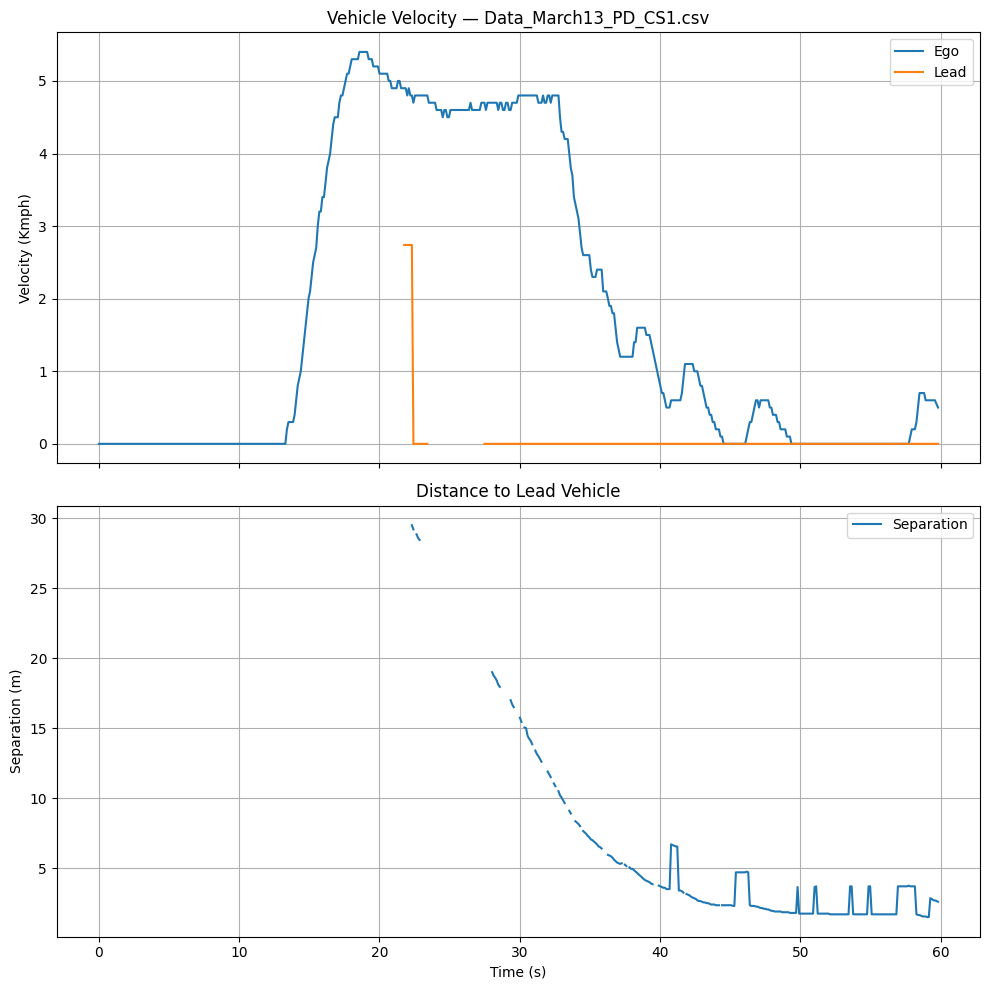

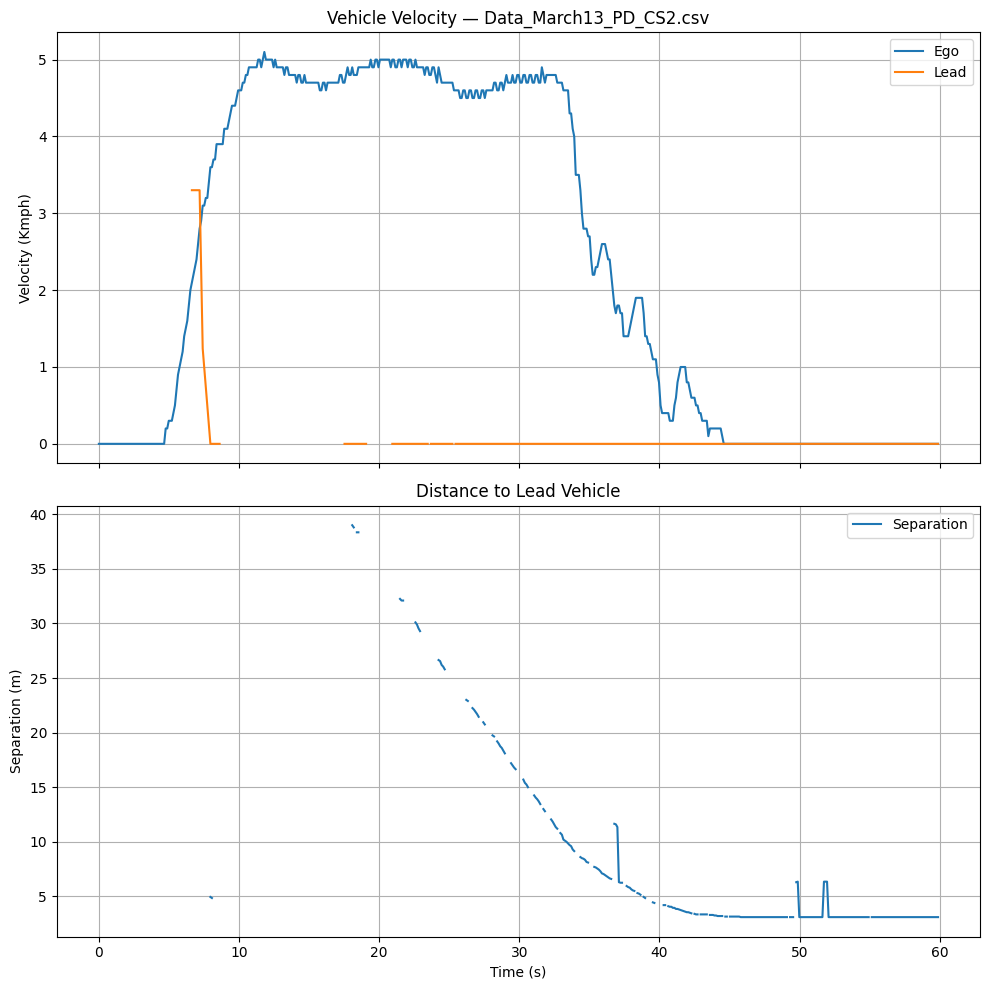

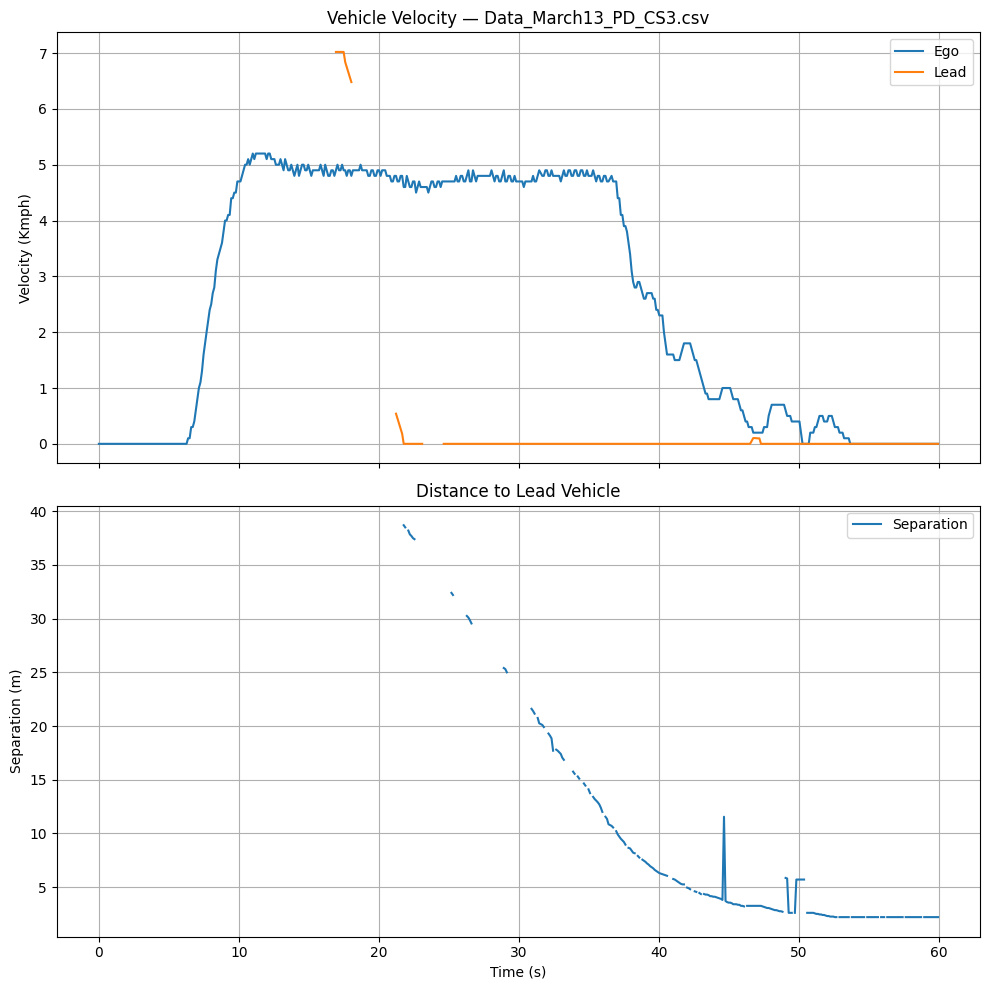

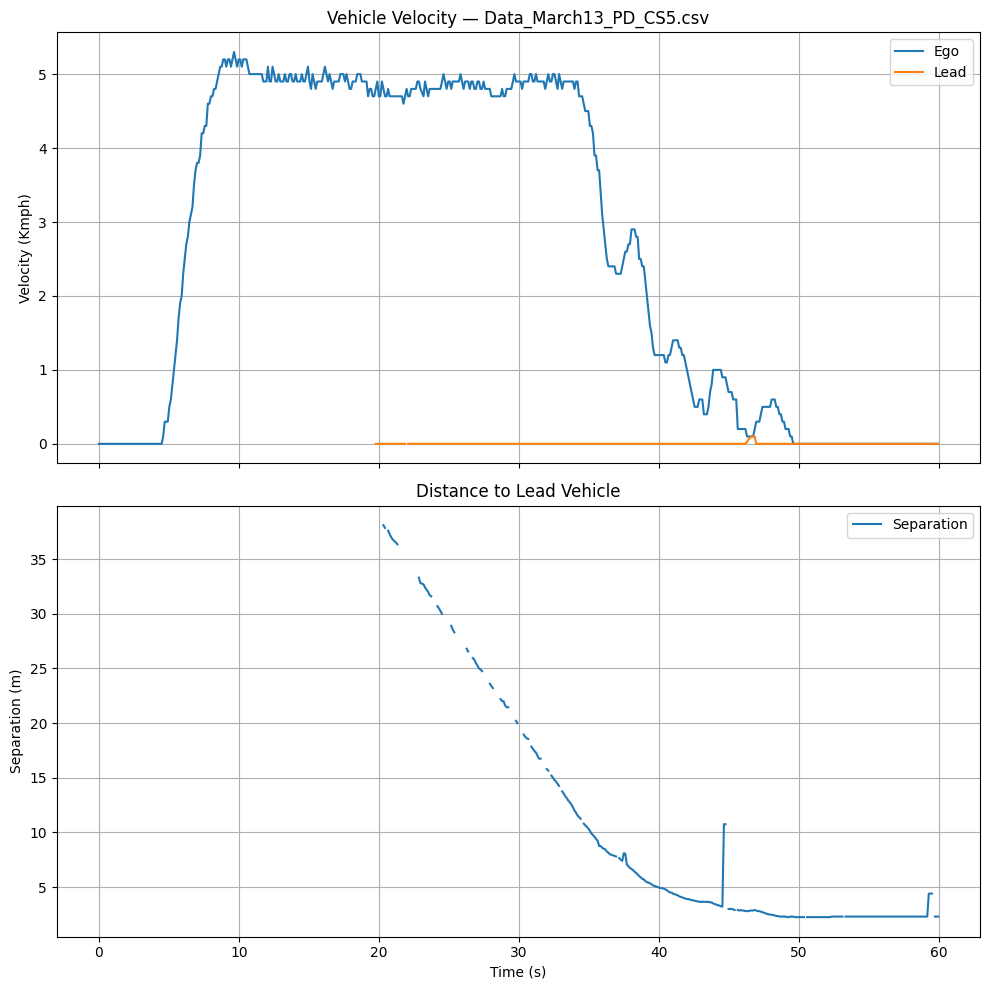

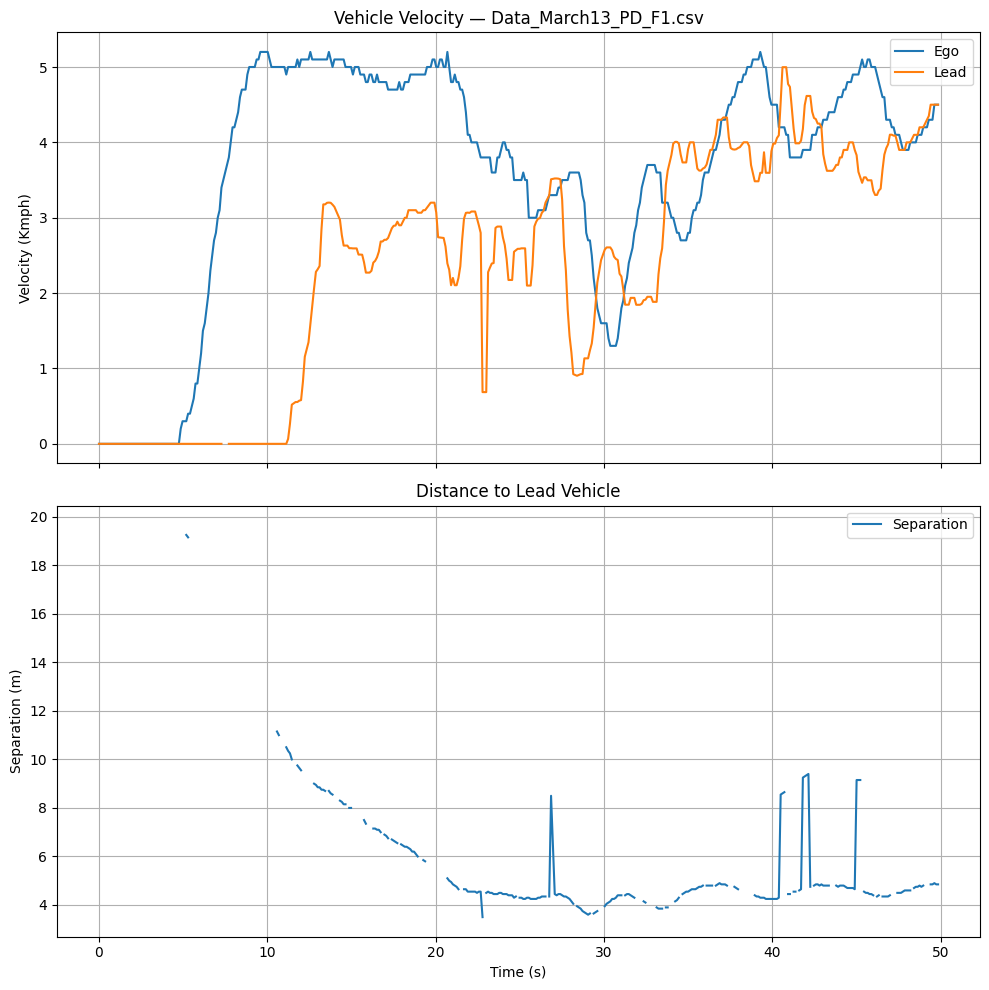

In [417]:
for file, df in data.items():
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # ---- Velocity ----
    axes[0].plot(df["Time"], df["Ego_Velocity_kmph_clean"], label="Ego")
    if "Obs_Velocity_kmph_clean" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_kmph_clean"], linestyle="-", label="Lead")

    # ---- Separation ----
    if "Separation(m)" in df.columns:
        axes[1].plot(df["Time"], df["Separation(m)"], label="Separation")

    axes[0].set_ylabel("Velocity (Kmph)")
    axes[0].set_title(f"Vehicle Velocity — {file}")

    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Distance to Lead Vehicle")

    for ax in axes:
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()

## For 2.2 Data Set

In [418]:
# path setup
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "Auto_Logged_data_March13")
# choose files to plot
selected_files = ["Data_March13_PD_CS2.csv"]
print("Selected files:")
for f in selected_files:
    print(f)

data = {}
for file in selected_files:
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)
    data[file] = df
    print(file, "loaded")
    display(df.head())
    
df["Time"] = df["Time(s)"] - df["Time(s)"].iloc[0]
df["Ego_Velocity_kmph"] = df["Ego_Velocity(m/s)"] * (18/5)
if "Obs_Velocity(m/s)" in df.columns:
    df["Obs_Velocity_kmph"] = df["Obs_Velocity(m/s)"] * (18/5)

Selected files:
Data_March13_PD_CS2.csv
Data_March13_PD_CS2.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s)
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000009
1,0.0,0.0,NaN,NaN,NaN,NaN,1.248120
2,0.0,0.0,NaN,NaN,NaN,NaN,1.357877
3,0.0,0.0,NaN,NaN,NaN,NaN,1.467689
4,0.0,0.0,NaN,NaN,NaN,NaN,1.577563


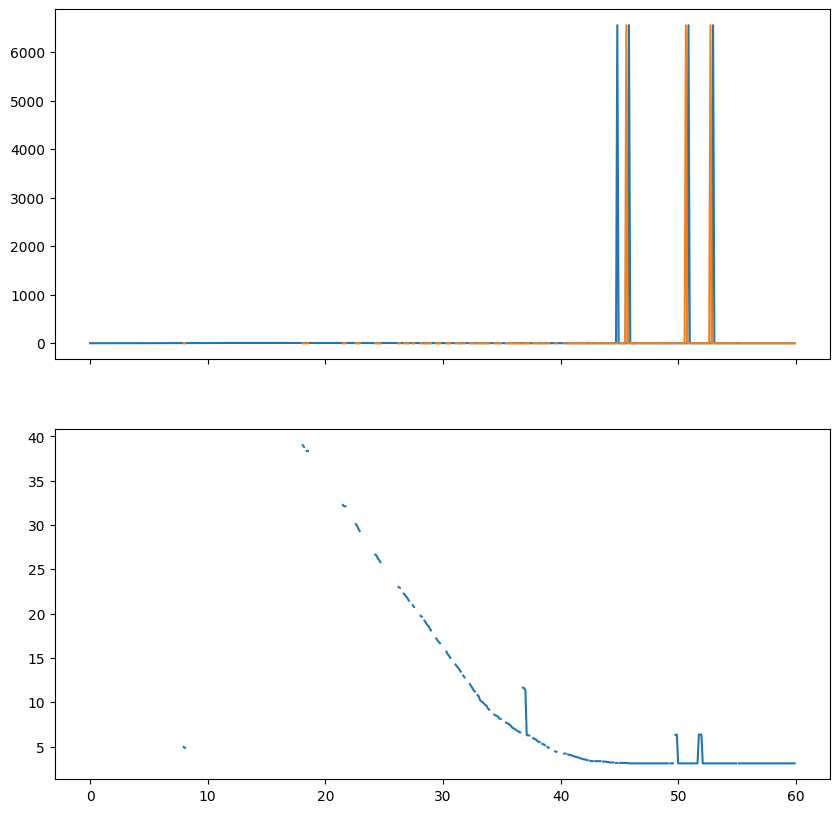

In [419]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], label="Ego")
if "Obs_Velocity_kmph" in df.columns:
    axes[0].plot(df["Time"], df["Obs_Velocity_kmph"], linestyle="-", label="Lead")   

separation = df["Separation(m)"] if "Separation(m)" in df.columns else None
if separation is not None:
    axes[1].plot(df["Time"], separation, label="Separation")       

plt.show()